In [1]:
import os
import shutil
import pandas as pd
import numpy as np
from tqdm import tqdm

import cv2
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'

# Đường dẫn file nhãn (Ground Truth)
TRAIN_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_GroundTruth.csv')
TRAIN_META = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Metadata.csv')
TEST_CSV = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_GroundTruth.csv')

train_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

WORKING_DIR = ROOT_FOLDER
PROCESSED_DIR = '/kaggle/working/processed_images/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Tiền Xử Lý Ảnh

In [3]:
def dull_razor_and_enhance(image_path):
    # Đọc ảnh gốc
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- BƯỚC 1: XÓA LÔNG (Dull Razor - Lec 07: Morphological) ---
    # Chuyển sang ảnh xám để xử lý hình thái học
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Tạo cấu trúc phần tử (Structuring Element) - Lec 07, trang 3
    # Chúng ta dùng kernel 17x17 để quét các sợi lông
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))

    # Phép toán Black-hat: Giúp lấy ra các chi tiết tối (lông) trên nền sáng (da)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Tạo Mask (mặt nạ): Chuyển ảnh blackhat về nhị phân
    # Các sợi lông sẽ có màu trắng (255), vùng da có màu đen (0)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Inpainting: "Vá" ảnh. Thay thế các pixel trắng trong mask bằng
    # các pixel lân cận để xóa sợi lông một cách tự nhiên.
    img_clean = cv2.inpaint(img_rgb, mask, 1, cv2.INPAINT_TELEA)

    # --- BƯỚC 2: KHỬ NHIỄU (Lec 04: Spatial Filtering) ---
    # Dùng Median Filter (Lec 04, trang 35) để khử nhiễu muối tiêu và làm mịn da
    img_smooth = cv2.medianBlur(img_clean, 3)

    # --- BƯỚC 3: TĂNG CƯỜNG TƯƠNG PHẢN (Lec 03: Histogram Transformation) ---
    # Chuyển sang hệ màu LAB để chỉ tác động vào cường độ sáng (L)
    # mà không làm thay đổi màu sắc y tế của bệnh.
    lab = cv2.cvtColor(img_smooth, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Áp dụng CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    # Gộp lại và chuyển về RGB
    img_final = cv2.merge((l_enhanced, a, b))
    img_final = cv2.cvtColor(img_final, cv2.COLOR_LAB2RGB)

    return img_rgb, img_final

In [4]:
classes = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

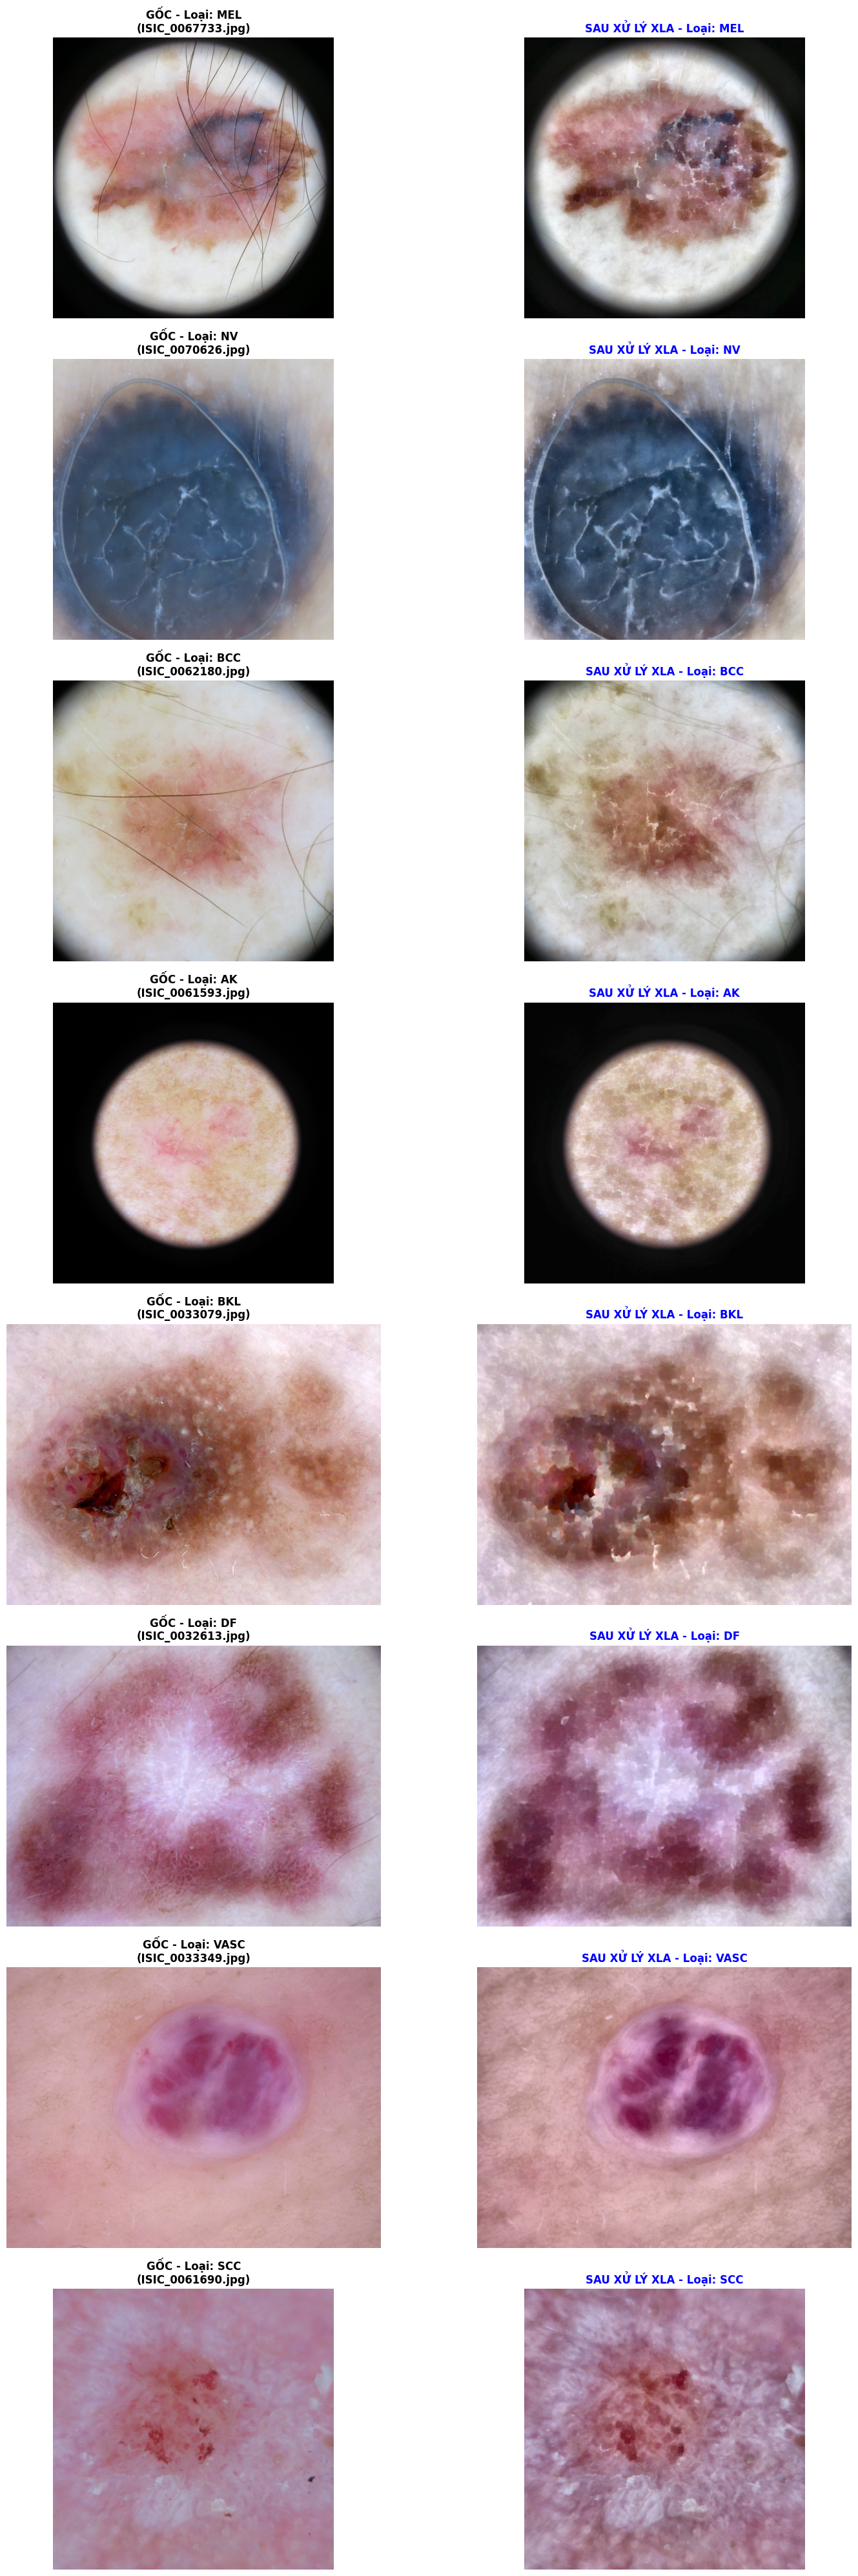

In [5]:
df_train = pd.read_csv(TRAIN_CSV)

def get_8_samples_by_class(df):
    sample_list = []
    for cls in classes:
        # Lọc các ảnh thuộc lớp này
        subset = df[df[cls] == 1.0]
        if not subset.empty:
            # Chọn ngẫu nhiên 1 ảnh
            img_id = subset.sample(1)['image'].values[0]
            # Đảm bảo có đuôi .jpg
            file_name = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else img_id
            sample_list.append((file_name, cls))
    return sample_list

# 3. THỰC HIỆN LẤY MẪU
samples = get_8_samples_by_class(df_train)

# 4. HIỂN THỊ KẾT QUẢ SO SÁNH (8 hàng x 2 cột)
plt.figure(figsize=(16, 40))

for i, (file_name, cls_name) in enumerate(samples):
    # Đường dẫn ảnh gốc trong folder đã giải nén
    path = os.path.join(train_img_folder, file_name)

    # Thực hiện tiền xử lý XLA
    orig, proc = dull_razor_and_enhance(path)

    if orig is not None:
        # Cột bên trái: Ảnh gốc
        plt.subplot(8, 2, 2*i + 1)
        plt.imshow(orig)
        plt.title(f"GỐC - Loại: {cls_name}\n({file_name})", fontsize=12, fontweight='bold')
        plt.axis('off')

        # Cột bên phải: Ảnh sau xử lý
        plt.subplot(8, 2, 2*i + 2)
        plt.imshow(proc)
        plt.title(f"SAU XỬ LÝ XLA - Loại: {cls_name}", fontsize=12, color='blue', fontweight='bold')
        plt.axis('off')
    else:
        print(f"⚠️ Không tìm thấy file: {path}")

plt.tight_layout()
plt.show()

In [6]:
DEBUG_COUNT = 25000

df_full = pd.read_csv(TRAIN_CSV)
df_full = df_full[df_full['UNK'] != 1.0]
df_sample = df_full.sample(n=DEBUG_COUNT, random_state=42).copy()
df_sample['image_file'] = df_sample['image'].apply(lambda x: f"{x}.jpg")

# 3. LÀM SẠCH THƯ MỤC ĐẦU RA (Xóa cũ tạo mới)
if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 4. VÒNG LẶP XỬ LÝ XLA (DIP)
print(f"🚀 Bắt đầu xử lý XLA cho {DEBUG_COUNT} ảnh...")

for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    img_name = row['image_file']
    input_path = os.path.join(train_img_folder, img_name)
    output_path = os.path.join(PROCESSED_DIR, img_name)

    if os.path.exists(input_path):
        # Gọi hàm XLA đã định nghĩa (Dull Razor + Median + CLAHE)
        _, processed_img = dull_razor_and_enhance(input_path)

        if processed_img is not None:
            # Bước Sampling (Lec 02): Resize về 224x224
            processed_img_resized = cv2.resize(processed_img, (224, 224))
            # Lưu ảnh vật lý vào folder
            cv2.imwrite(output_path, cv2.cvtColor(processed_img_resized, cv2.COLOR_RGB2BGR))

print(f"\n✅ Xử lý xong! {len(os.listdir(PROCESSED_DIR))} ảnh sạch đã sẵn sàng tại: {PROCESSED_DIR}")

🚀 Bắt đầu xử lý XLA cho 25000 ảnh...


100%|██████████| 25000/25000 [32:11<00:00, 12.94it/s]


✅ Xử lý xong! 25000 ảnh sạch đã sẵn sàng tại: /kaggle/working/processed_images/


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import (Layer, Conv2D, Multiply,
                                      GlobalAveragePooling2D, Dense, Dropout)

# 1. ĐỊNH NGHĨA LỚP SOFT ATTENTION (đúng công thức: energy -> spatial softmax -> nhân trọng số)
class SoftAttention(Layer):
    def __init__(self, **kwargs):
        super(SoftAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch, h, w, ch) — feature map đầu vào từ backbone
        # Conv 1x1 để nén C kênh xuống còn 1 kênh, tính điểm năng lượng e_ij
        self.energy_conv = Conv2D(
            filters=1,
            kernel_size=(1, 1),
            padding='same',
            activation='linear',
            name='energy_score'
        )
        self.energy_conv.build(input_shape)
        super(SoftAttention, self).build(input_shape)

    def call(self, x):
        # x shape: (batch, h, w, ch)

        # 1. Tính năng lượng e_ij = Watt * f_ij + batt
        e = self.energy_conv(x)  # (batch, h, w, 1)

        # 2. Chuẩn hóa Softmax trên toàn bộ không gian (H*W), không phải theo từng hàng/cột riêng
        orig_shape = tf.shape(e)
        b, h, w, c = orig_shape[0], orig_shape[1], orig_shape[2], orig_shape[3]

        flat = tf.reshape(e, (b, h * w, c))
        softmax_flat = tf.nn.softmax(flat, axis=1)
        alpha = tf.reshape(softmax_flat, (b, h, w, c))  # (batch, h, w, 1)

        # 3. Nhân trọng số attention vào feature map gốc
        F_att = Multiply()([x, alpha])
        return F_att

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super(SoftAttention, self).get_config()
        return config

In [8]:
def build_hybrid_model(num_classes=8):
    # Khởi tạo MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Đóng băng 100 lớp đầu tiên để giữ đặc trưng cơ bản và chống Overfitting
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False

    inputs = base_model.input
    f = base_model.output 

    # Gọi trực tiếp lớp SoftAttention đã định nghĩa ở trên
    F_att = SoftAttention(name='soft_attention')(f)

    # Các lớp phân loại cuối cùng
    x = GlobalAveragePooling2D()(F_att)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=predictions)
    return model

In [9]:
# 3. KHỞI TẠO MÔ HÌNH
model = build_hybrid_model(num_classes=8)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1785511051.007846      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785511051.010552      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 1,872,969 (7.14 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

label_columns = classes

# 1. BỔ SUNG DATA AUGMENTATION CHO TẬP TRAIN (Chống Học vẹt)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,        # Xoay ảnh ngẫu nhiên tối đa 20 độ
    width_shift_range=0.1,    # Dịch chuyển ảnh theo chiều ngang 10%
    height_shift_range=0.1,   # Dịch chuyển ảnh theo chiều dọc 10%
    horizontal_flip=True,     # Tự động lật ngang ảnh
    zoom_range=0.1            # Phóng to/thu nhỏ ngẫu nhiên 10%
)

# 2. TẬP VALIDATION (Chỉ áp dụng tiền xử lý chuẩn, KHÔNG biến đổi ảnh)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. CHIA DỮ LIỆU
train_df, val_df = train_test_split(df_sample, test_size=0.2, random_state=42)

print(f"📊 Kiểm tra số lượng dòng trong Dataframe:")
print(f"- Tập Train: {len(train_df)} dòng")
print(f"- Tập Val: {len(val_df)} dòng")

# 4. KHỞI TẠO LUỒNG DỮ LIỆU ĐỂ HUẤN LUYỆN
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=PROCESSED_DIR,
    x_col="image_file",
    y_col=label_columns,
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

📊 Kiểm tra số lượng dòng trong Dataframe:
- Tập Train: 20000 dòng
- Tập Val: 5000 dòng
Found 20000 validated image filenames.
Found 5000 validated image filenames.


In [11]:
from sklearn.utils.class_weight import compute_class_weight

# Lấy class index (0-7) cho từng ảnh trong tập train, dựa trên cột one-hot
y_train_integers = train_df[classes].values.argmax(axis=1)

# Tính trọng số nghịch đảo theo tần suất xuất hiện của từng lớp
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

# Chuyển thành dict {index_lớp: trọng_số} — đúng định dạng model.fit() cần
class_weight_dict = dict(enumerate(class_weights_array))

print("📊 Trọng số từng lớp (class_weight):")
for i, cls_name in enumerate(classes):
    print(f"  {cls_name}: {class_weight_dict[i]:.3f}")

📊 Trọng số từng lớp (class_weight):
  MEL: 0.697
  NV: 0.246
  BCC: 0.949
  AK: 3.704
  BKL: 1.212
  DF: 14.368
  VASC: 12.953
  SCC: 5.040


In [12]:
# 1. Các cơ chế giám sát (Callbacks)
callbacks = [
    # Dừng huấn luyện nếu độ chính xác trên tập Val không tăng sau 5 vòng (Epoch)
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),

    # Tự động giảm tốc độ học nếu mô hình bị kẹt (Lec 06)
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),

    # Lưu lại phiên bản tốt nhất vào /kaggle/working để tải về sau khi chạy xong
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/best_hybrid_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

EPOCHS = 50

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_df) // 32,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=len(val_df) // 32,
    callbacks=callbacks,
    class_weight=class_weight_dict   # <-- thêm dòng này
)

Epoch 1/50


2026-07-31 15:18:00.046124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 15:18:00.183304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785511087.326926      79 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.3935 - loss: 1.9165
Epoch 1: val_accuracy improved from None to 0.60036, saving model to /kaggle/working/best_hybrid_model.h5



Epoch 1: finished saving model to /kaggle/working/best_hybrid_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 346ms/step - accuracy: 0.4706 - loss: 1.7082 - val_accuracy: 0.6004 - val_loss: 1.2415 - learning_rate: 1.0000e-04
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.5483 - loss: 1.3153
Epoch 2: val_accuracy did not improve from 0.60036
625/625 ━━━━━━━━━━━━━━━━━━━━ 213s 341ms/step - accuracy: 0.5594 - loss: 1.2595 - val_accuracy: 0.6000 - val_loss: 1.1382 - learning_rate: 1.0000e-04
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.5997 - loss: 1.1072
Epoch 3: val_accuracy improved from 0.60036 to 0.62861, saving model to /kaggle/working/best_hybrid_model.h5



Epoch 3: finished saving model to /kaggle/working/best_hybrid_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 209s 335ms/step - accuracy: 0.5988 - loss: 1.0864 - val_accuracy: 0.6286 - val_loss: 1.0380 - learning_rate: 1.0000e-04
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.6097 - loss: 0.9758
Epoch 4: val_accuracy did not improve from 0.62861
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 330ms/step - accuracy: 0.6146 - loss: 0.9743 - val_accuracy: 0.5721 - val_loss: 1.1631 - learning_rate: 1.0000e-04
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.6325 - loss: 0.8730
Epoch 5: val_accuracy did not improve from 0.62861
625/625 ━━━━━━━━━━━━━━━━━━━━ 211s 338ms/step - accuracy: 0.6317 - loss: 0.8799 - val_accuracy: 0.5944 - val_loss: 1.0346 - learning_rate: 1.0000e-04
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.6490 - loss: 0.8020
Epoch 6: val_accuracy did not improve from 0.62861
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 333ms/step - accuracy: 0.6560 

...


Epoch 9: finished saving model to /kaggle/working/best_hybrid_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.6972 - loss: 0.6416 - val_accuracy: 0.6573 - val_loss: 0.9322 - learning_rate: 1.0000e-04
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7018 - loss: 0.5963
Epoch 10: val_accuracy did not improve from 0.65725
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.7056 - loss: 0.5914 - val_accuracy: 0.6370 - val_loss: 0.9959 - learning_rate: 1.0000e-04
Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7222 - loss: 0.5383
Epoch 11: val_accuracy did not improve from 0.65725
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.7243 - loss: 0.5490 - val_accuracy: 0.6212 - val_loss: 0.9868 - learning_rate: 1.0000e-04
Epoch 12/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.7381 - loss: 0.5122
Epoch 12: val_accuracy did not improve from 0.65725
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 332ms/step - accuracy: 0


Epoch 13: finished saving model to /kaggle/working/best_hybrid_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 325ms/step - accuracy: 0.7634 - loss: 0.4353 - val_accuracy: 0.6639 - val_loss: 0.9057 - learning_rate: 2.0000e-05
Epoch 14/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7678 - loss: 0.4135
Epoch 14: val_accuracy improved from 0.66386 to 0.67889, saving model to /kaggle/working/best_hybrid_model.h5



Epoch 14: finished saving model to /kaggle/working/best_hybrid_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 325ms/step - accuracy: 0.7724 - loss: 0.4056 - val_accuracy: 0.6789 - val_loss: 0.8780 - learning_rate: 2.0000e-05
Epoch 15/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.7729 - loss: 0.3889
Epoch 15: val_accuracy did not improve from 0.67889
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 322ms/step - accuracy: 0.7695 - loss: 0.3996 - val_accuracy: 0.6759 - val_loss: 0.8964 - learning_rate: 2.0000e-05
Epoch 16/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7800 - loss: 0.3696
Epoch 16: val_accuracy did not improve from 0.67889
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 324ms/step - accuracy: 0.7800 - loss: 0.3786 - val_accuracy: 0.6747 - val_loss: 0.8757 - learning_rate: 2.0000e-05
Epoch 17/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7805 - loss: 0.3708
Epoch 17: val_accuracy improved from 0.67889 to 0.69291, saving model to /kaggle/working/best_hybrid_model.h5


Epoch 17: finished saving model to /kaggle/working/best_hybrid_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 324ms/step - accuracy: 0.7787 - loss: 0.3703 - val_accuracy: 0.6929 - val_loss: 0.8519 - learning_rate: 2.0000e-05
Epoch 18/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.7864 - loss: 0.3531
Epoch 18: val_accuracy improved from 0.69291 to 0.70553, saving model to /kaggle/working/best_hybrid_model.h5



Epoch 18: finished saving model to /kaggle/working/best_hybrid_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 321ms/step - accuracy: 0.7871 - loss: 0.3507 - val_accuracy: 0.7055 - val_loss: 0.8334 - learning_rate: 2.0000e-05
Epoch 19/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7969 - loss: 0.3378
Epoch 19: val_accuracy did not improve from 0.70553
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 325ms/step - accuracy: 0.7929 - loss: 0.3404 - val_accuracy: 0.6921 - val_loss: 0.8576 - learning_rate: 2.0000e-05
Epoch 20/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.7947 - loss: 0.3230
Epoch 20: val_accuracy did not improve from 0.70553
625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 326ms/step - accuracy: 0.7954 - loss: 0.3284 - val_accuracy: 0.6911 - val_loss: 0.8649 - learning_rate: 2.0000e-05
Epoch 21/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8023 - loss: 0.3297
Epoch 21: val_accuracy did not improve from 0.70553
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 325ms/step - accuracy: 

#Test

🔄 Đang nạp file Ground Truth của tập Test...
Tổng mẫu test gốc: 8238 | Sau khi loại UNK: 6191
Đã lấy mẫu: 1000 ảnh (100% thuộc 8 lớp đã biết)
🛠️ Đang xử lý DIP (Dull Razor + CLAHE) cho 1000 mẫu test...


100%|██████████| 1000/1000 [01:21<00:00, 12.26it/s]



🧠 AI đang dự đoán...


  0%|          | 0/1000 [00:00<?, ?it/s]2026-07-31 16:38:54.703835: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 16:38:54.858197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 16:38:54.991849: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
100%|██████████| 1000/1000 [01:37<00:00, 10.30it/s]



📊 CLOSED-SET: 1000 mẫu (100% thuộc 8 lớp đã biết, không lẫn UNK)


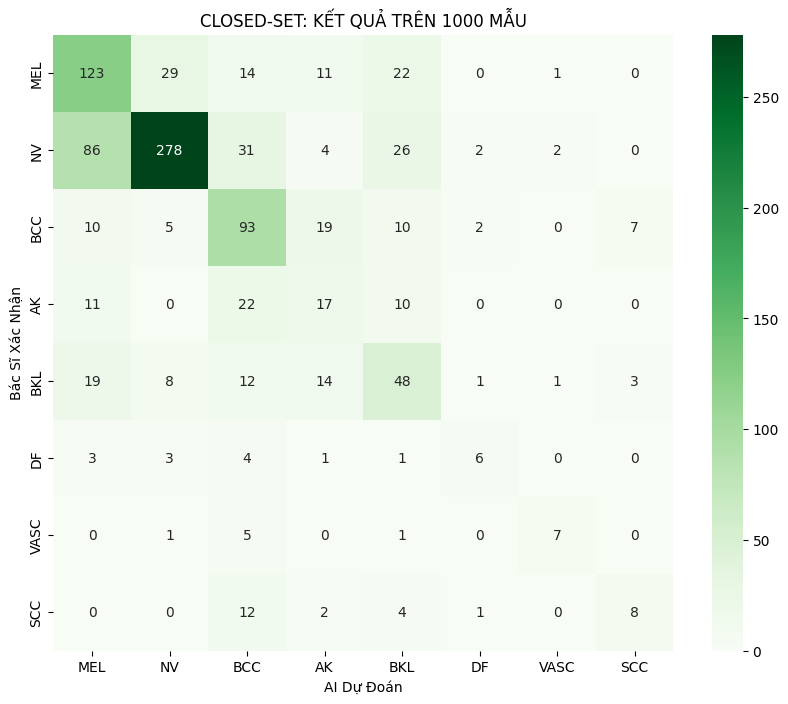


📊 BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

         MEL       0.49      0.61      0.54       200
          NV       0.86      0.65      0.74       429
         BCC       0.48      0.64      0.55       146
          AK       0.25      0.28      0.27        60
         BKL       0.39      0.45      0.42       106
          DF       0.50      0.33      0.40        18
        VASC       0.64      0.50      0.56        14
         SCC       0.44      0.30      0.36        27

    accuracy                           0.58      1000
   macro avg       0.51      0.47      0.48      1000
weighted avg       0.62      0.58      0.59      1000



In [13]:
# --- 0. LOAD LẠI ĐÚNG BẢN TỐT NHẤT ĐÃ LƯU ---
model.load_weights('/kaggle/working/best_hybrid_model.h5')

# --- 1. CẤU HÌNH ---
TEST_COUNT = 1000
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']   # 8 lớp, không có UNK
PROCESSED_FINAL_TEST_DIR = '/kaggle/working/final_test_images_real/'
ROOT_FOLDER = '/kaggle/input/datasets/ruii2401/isic-2019'
test_img_folder = os.path.join(ROOT_FOLDER, 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input')

print("🔄 Đang nạp file Ground Truth của tập Test...")
df_test_full = pd.read_csv(TEST_CSV)

# --- 2. LOẠI UNK NGAY TỪ ĐẦU, RỒI MỚI SAMPLE ---
df_test_no_unk = df_test_full[df_test_full['UNK'] != 1.0].copy()
print(f"Tổng mẫu test gốc: {len(df_test_full)} | Sau khi loại UNK: {len(df_test_no_unk)}")

df_test_sample = df_test_no_unk.sample(n=TEST_COUNT, random_state=42)
print(f"Đã lấy mẫu: {len(df_test_sample)} ảnh (100% thuộc 8 lớp đã biết)")

# --- 3. XỬ LÝ DIP ---
if os.path.exists(PROCESSED_FINAL_TEST_DIR):
    shutil.rmtree(PROCESSED_FINAL_TEST_DIR)
os.makedirs(PROCESSED_FINAL_TEST_DIR, exist_ok=True)

print(f"🛠️ Đang xử lý DIP (Dull Razor + CLAHE) cho {TEST_COUNT} mẫu test...")
for _, row in tqdm(df_test_sample.iterrows(), total=TEST_COUNT):
    img_id = row['image']
    input_path = os.path.join(test_img_folder, f"{img_id}.jpg")
    output_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{img_id}.jpg")
    if os.path.exists(input_path):
        _, proc = dull_razor_and_enhance(input_path)
        if proc is not None:
            proc = cv2.resize(proc, (224, 224))
            cv2.imwrite(output_path, cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))

# --- 4. DỰ ĐOÁN ---
y_true_closed, y_pred_closed = [], []
sample_confidences = []
sample_top_idx = []

print("\n🧠 AI đang dự đoán...")
for _, row in tqdm(df_test_sample.iterrows(), total=len(df_test_sample)):
    img_id = row['image']
    img_path = os.path.join(PROCESSED_FINAL_TEST_DIR, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img.astype(np.float32))
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img, verbose=0)[0]
    top_idx = np.argmax(preds)
    confidence = preds[top_idx]

    true_idx = np.argmax(row[CLASSES].values)

    y_true_closed.append(true_idx)
    y_pred_closed.append(top_idx)
    sample_confidences.append(confidence)
    sample_top_idx.append(top_idx)

sample_confidences = np.array(sample_confidences)
sample_top_idx = np.array(sample_top_idx)

# --- 5. VẼ MA TRẬN NHẦM LẪN ---
print(f"\n📊 CLOSED-SET: {len(y_true_closed)} mẫu (100% thuộc 8 lớp đã biết, không lẫn UNK)")
plt.figure(figsize=(10, 8))
cm_closed = confusion_matrix(y_true_closed, y_pred_closed)
sns.heatmap(cm_closed, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'CLOSED-SET: KẾT QUẢ TRÊN {len(y_true_closed)} MẪU')
plt.xlabel('AI Dự Đoán')
plt.ylabel('Bác Sĩ Xác Nhận')
plt.show()

# --- 6. BÁO CÁO CHI TIẾT ---
print("\n📊 BÁO CÁO CHI TIẾT:")
present_labels = np.unique(np.concatenate((y_true_closed, y_pred_closed)))
present_names = [CLASSES[i] for i in present_labels]
print(classification_report(y_true_closed, y_pred_closed, labels=present_labels, target_names=present_names))

In [14]:
train_files = set(train_df['image_file'])
val_files = set(val_df['image_file'])
overlap = train_files & val_files
print(f"Số ảnh trùng giữa train và val: {len(overlap)}")


Số ảnh trùng giữa train và val: 0
